# Massive CV Ensemble
* 5 folds x 40 seeds x 5 Configs GBSA Model
* Use GBSA and LGBM

In [22]:
!pip install -q scikit-survival

In [23]:
import numpy as np
import pandas as pd
import warnings
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, RepeatedKFold
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.util import Surv
import sys
import platform
import torch
import sklearn
import sksurv
import kagglehub
import os

warnings.filterwarnings("ignore")

# Enviorment report

In [24]:

print("Python: ", sys.version.split()[0])
print("OS: ", platform.platform())
print("Scikit-learn: ", sklearn.__version__)
print("Scikit-survival: ", sksurv.__version__)

Python:  3.11.14
OS:  Linux-5.15.167.4-microsoft-standard-WSL2-x86_64-with-glibc2.39
Scikit-learn:  1.8.0
Scikit-survival:  0.27.0


# Paths

In [25]:
COMP_DIR = kagglehub.competition_download('WiDSWorldWide_GlobalDathon26')
metadata_path = os.path.join(COMP_DIR, 'metaData.csv')
train_path = os.path.join(COMP_DIR, 'train.csv')
test_path = os.path.join(COMP_DIR, 'test.csv')

# Utility

In [26]:
def set_seed(seed=42):
    np.random.seed(seed)


## Feature Engineering

## Basic Parameters
### 1. `dist`
```python
dist = result["dist_min_ci_0_5h"].clip(lower=1)
```

* 초기 0~5h동안 대피구역까지의 최소거리 $m$단위
* `clip(lower=1)`은 거리가 0까지 내려가지 않도록 최소 1로 잘라서, 후에 있을 $\log$, $\frac{1}{dist}$계산이 가능하도록 함

### 2. `speed`
```python
speed = result["closing_speed_m_per_h"]
```

* 산불이 대피구역 방향으로 얼마나 빠르게 접근하는지를 나타내는 속도

### 3. `perimeters`
```python
perimeters = result["num_perimeters_0_5h"]
```

* 초기 0~5시간 동안 관측된 perimeter(화재 외곽선) 개수를 가져옴. -> 정확히 무엇을 의미하는지 추가 조사 필요
* 보통 perimeter가 많으면 화재 활동성이 더 크다고 볼 수 있음.

### 4. `area_first`

```python
area_first = result["area_first_ha"]
```

* 초기 화재 면적(ha 단위)

### 5. `fire_radius`
```python
fire_radius = np.sqrt(area_first * 10000 / np.pi)
```
* 초기 화재 발생면적이 원이라고 가정했을 때의 초기 화재 발생반경
* $1ha = 10,000m^2$이므로 `area_first` $\times 10,000$으로 단위를 $ha$에서 $m^2$로 변환 후, 원의 넓이 공식 $A= \pi r^2$에서 $r = \sqrt(\frac{A}{\pi})$ 사용
---
## Distance transformations
### 1. `"log_distance"`
```python
result["log_distance"] = np.log1p(dist)
```

* $\log(1+dist)$으로 `dist`를 변환
* $\log$인지라 작은 거리는 차이를 크게 큰 거리는 차이를 작게 변환 
* $\log(1+dist)$라서 0 근처도 안전함.

### 2. `"inv_distance"`
```python
result["inv_distance"] = 1 / (dist / 1000 + eps)
```
**위험도를 나타내는 피처**
* 거리의 역수
* 가까울수록 값은 커짐
* 1000으로 나누어 $m$를 $km$로 eps은 0으로 나누는 것을 방지

### 3. `"sqrt_distance"`
```python
result["sqrt_distance"] = np.sqrt(dist)
```
* `dist`의 제곱근 변환
* 로그변환보다는 약하게, 원본보다는 강하게 거리의 차이를 좁힘

### 4. `"dist_km_sq"`
```python
result["dist_km_sq"] = (dist / 1000) ** 2
```
* 거리(km)의 제곱.
* 거리와 위험도의 비선형 관계를 모델이 더 쉽게 잡도록 도와줌.

### 5. `"dist_rank"`
```python
result["dist_rank"] = dist.rank(pct=True)
```

* 각 샘플의 거리가 전체 데이터에서 어느 정도 순위인지 백분위로 표현. -> 실제 테스트에서는 전체 데이터를 train을 포함한 걸로 해야 할지 test만 해야 할지
* 절대 거리 대신 상대적으로 “얼마나 가까운 편인가”를 넣는 것.

---
## Area-to-distance
### 1. `"radius_to_dist"`
```python
result["radius_to_dist"] = fire_radius / dist
```
* 화재 반경이 대피구역까지 거리 대비 얼마나 큰지 나타냄.
* 불이 크고 대피구역이 가까울수록 값이 커짐.

### 2. `"area_to_dist_ratio"`
```python
result["area_to_dist_ratio"] = area_first / (dist / 1000 + 0.1)
```

* 화재 면적을 거리(km)로 나눈 값.
* 큰 화재가 가까이 있을수록 위험하다는 아이디어.

### 3. `"log_area_dist_ratio"`
```python
result["log_area_dist_ratio"] = np.log1p(area_first) - np.log1p(dist)
```
* 로그 공간에서 면적과 거리의 차이를 표현.

* 큰 화재 + 짧은 거리 조합을 더 안정적으로 나타냄. (산불이 진행해야 할 거리 표현)

* 사실상 $\log(\frac{1+A}{1+d})$와 동일 따라서 아래와 같이 바꿀 수 있음
    ```python
    np.log((1+area_first)/(1+dist))
    ```
---
## Movement / kinematics
### 1. `"has_movement"`
```python
result["has_movement"] = (perimeters > 1).astype(float)
```
* `perimeters`가 1개보다 많으면 “움직임/확장 있음”으로 보고 1, 아니면 0으로 둠.
* 이진 피처로 단순화해서 모델이 쓰기 쉽게 만든 것.

### 2. `closing_pos`
```python
closing_pos = speed.clip(lower=0)
```

* 접근 속도가 음수면(멀어지는 방향이면) 0으로 잘라버림.
* 즉 실제 “다가오는 속도”만 남김. -> 그럼 아예 조건식으로 얘가 0이면 prob를 다 0으로 출력해도 되지 않나?

### 3. `"eta_hours"`
```python
result["eta_hours"] = np.where(closing_pos > min_speed, dist / closing_pos, max).clip(max=max_hours)
```
* `dist / speed` 형태.
* 속도가 너무 작거나 0 (0.01보다 작으면)이면 사실상 도달 안 하는 것으로 보고 `max_hours`(9999)를 넣음.
* 마지막 `clip(max=max_hours)`는 너무 큰 값도 제한.

## Movement / Kinematics Features

### `log_eta`

```python
result["log_eta"] = np.log1p(result["eta_hours"].clip(0, 9999))
```

ETA를 로그 변환해서 스케일을 줄인다.

- ETA 값이 매우 커질 수 있기 때문에 로그 변환으로 스케일을 압축
- 매우 큰 ETA 값들의 영향력을 줄여 모델 학습 안정성을 높임

---

### `radial_growth`

```python
radial_growth = result["radial_growth_rate_m_per_h"].clip(lower=0)
```

화재가 **반경 방향으로 퍼지는 속도**를 가져온다.

- 음수 값은 화재가 줄어드는 경우이므로 0으로 잘라낸다
- 즉 화재의 **확산만 반영**

---

### `effective_closing_speed`

```python
effective_closing = closing_pos + radial_growth
result["effective_closing_speed"] = effective_closing
```

단순 접근 속도와 화재 확산 속도를 합친 값이다.

- `closing_pos`: 화재의 접근 속도
- `radial_growth`: 화재 확산 속도

즉 **화재 이동 + 화재 확산**을 동시에 고려한 실제 접근 속도.

---

### `eta_effective`

```python
result["eta_effective"] = np.where(
    effective_closing > 0.01,
    dist / effective_closing,
    9999
).clip(max=9999)
```

확산까지 고려한 ETA(도달 예상 시간).

- 단순 이동 기반 ETA보다 **물리적으로 더 의미 있는 값**
- 확산까지 고려하여 **실제 화재 도달 가능성**을 더 잘 반영

---

### `threat_score`

```python
result["threat_score"] = result["alignment_abs"] * speed / np.log1p(dist)
```

화재 위협 점수.

다음 세 요소를 동시에 반영한다.

- `alignment_abs`: 화재 이동 방향이 대피구역 방향과 얼마나 정렬되어 있는지
- `speed`: 화재 접근 속도
- `dist`: 대피구역까지 거리

즉 다음 조건일수록 값이 커진다.

- 대피구역 방향으로 이동
- 접근 속도가 빠름
- 거리가 가까움

→ **대피구역 쪽으로 빠르게, 가까이 접근하는가**를 표현하는 feature.

---

### `fire_urgency`

```python
result["fire_urgency"] = perimeters * speed
```

화재의 **활동성 + 접근 속도**를 동시에 반영하는 feature.

- perimeter 수가 많고
- 접근 속도가 빠를수록

값이 커진다.

즉 화재 상황이 **얼마나 급박한지**를 나타낸다.

---

### `growth_intensity`

```python
result["growth_intensity"] = result["area_growth_rate_ha_per_h"] * perimeters
```

화재 성장 강도.

- 면적 증가 속도
- perimeter 수

를 결합한 feature로 **화재가 얼마나 활발하게 성장하고 있는지**를 나타낸다.

---

## Distance Zone Features

### 1. `"zone_critical"`

```python
result["zone_critical"] = (dist < 5000).astype(float)
```

대피구역까지 거리가 **5km 미만**이면 1.

→ **가장 위험한 구간**

---

### 2. `"zone_warning"`

```python
result["zone_warning"] = ((dist >= 5000) & (dist < 10000)).astype(float)
```

거리 **5km ~ 10km**

→ **경고 구간**

---

### 3. `"zone_safe"`

```python
result["zone_safe"] = (dist >= 10000).astype(float)
```

거리 **10km 이상**

→ **상대적으로 안전한 구간**

---

이 세 feature는 **거리의 비선형 임계값 효과**를 모델이 쉽게 학습하도록 돕는다.

예를 들어:

- 3km vs 8km
- 8km vs 15km

이 차이는 단순 거리 차이 이상의 의미를 가질 수 있기 때문에  
**zone 기반 feature**를 추가한다.

---

## Temporal Features

### 1. `"is_summer"`

```python
result["is_summer"] = result["event_start_month"].isin([6, 7, 8]).astype(float)
```

화재 시작 월이 **6, 7, 8월이면 여름**으로 판단.

여름에는

- 기온 상승
- 건조 환경
- 산불 확산 위험 증가

등의 요인이 있을 수 있기 때문에 이를 반영한다.

---

### 2. `"is_afternoon"`

```python
result["is_afternoon"] = (
    (result["event_start_hour"] >= 12) &
    (result["event_start_hour"] < 20)
).astype(float)
```

화재 시작 시간이 **12시 ~ 20시 사이**이면 오후로 판단.

시간대에 따라

- 온도
- 풍속
- 대기 상태

등이 달라질 수 있으며  
이는 화재 확산 패턴에 영향을 줄 수 있다.
## 의문점
### 1. perimeters가 무엇을 의미하는지

### 2. `dist_rank`를 계산할 때 후에 실제 predict에서는 test만 넣어야 하는지 아니면 train도 넣어야 하는지

### 3. `"log_area_dist_ratio"`는 `fire_radius`가 아니라 면적이 들어가는지

In [27]:
def create_features(df: pd.DataFrame, eps=0.1, max_hours=9999, min_speed=0.01)-> pd.DataFrame:
    """
    Args:
        df (pd.DataFrame): Input DataFrame with raw features.
        eps (float): Small constant to avoid division by zero in transformations.
        max_hours (int): Maximum hours to cap time-based features for stability.
    Returns:
        pd.DataFrame: DataFrame with engineered features.
        
    ---
   

    ### 
    
    """
    result = df.copy()
    dist = result['dist_min_ci_0_5h'].clip(lower=1)
    speed = result['closing_speed_m_per_h']
    perimeters = result['num_perimeters_0_5h']
    area_first = result['area_first_ha'] 
    
    # Distance transformations
    result['log_distance'] = np.log1p(dist)
    result['inv_distance'] = 1 / (dist / 1000 + eps)
    result['sqrt_distance'] = np.sqrt(dist)
    result['inv_distance_sq'] = result['inv_distance'] ** 2
    result['sqrt_distance'] = np.sqrt(dist)
    result['dist_km'] = dist / 1000
    result['dsit_km_sq'] = (dist / 1000) ** 2
    result['dist_rank'] = dist.rank(pct=True)
    
    # Area-to-distance
    fire_radius = np.sqrt(area_first * 10000 / np.pi)
    result['radius_to_dist'] = fire_radius / (dist / 1000 + eps)
    result['area_to_dist_ratio'] = area_first / (dist / 1000 + eps)

# Data

In [28]:
metadata_df = pd.read_csv(metadata_path)
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

In [29]:
train_df.head()

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0


In [31]:
train_df['time_to_hit_hours'].max()

np.float64(66.99447413277778)

In [41]:
from sklearn.linear_model import LinearRegression

data = np.array([[1, 3501], [2, 2500], [3, 5000], [4, 6020], [5, 7500]])
x = data[:, 0].reshape(-1, 1)
y = data[:, 1]

model = LinearRegression()
model.fit(x, y)
predictions = model.predict(x)
print(predictions)
print(model.coef_, model.intercept_)

[2600.6 3752.4 4904.2 6056.  7207.8]
[1151.8] 1448.8000000000002


,hours,Distance (m)
0,1,3501
1,2,2500
2,3,5000
3,4,6020
4,5,7500


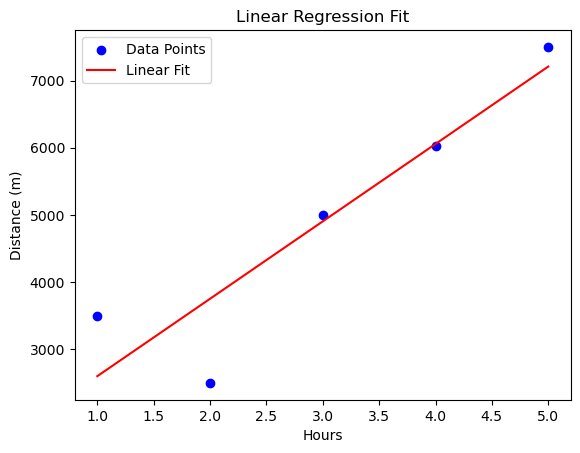

In [43]:
import matplotlib.pyplot as plt
plt.scatter(x, y, color='blue', label='Data Points')
plt.plot(x, predictions, color='red', label='Linear Fit')
plt.xlabel('Hours')
plt.ylabel('Distance (m)')
plt.title('Linear Regression Fit')
plt.legend()

df = pd.DataFrame({'hours': x.flatten(), 'Distance (m)': y})
display(df)
plt.show()